# Backtesting RSI + EMA Strategy on NIFTY

This project backtests a simple trading strategy using RSI and EMA indicators on NIFTY historical data.

Strategy Rules:
- Buy when RSI < 30 and price is above EMA
- Sell when RSI > 70

Tools Used:
- Python
- pandas
- numpy
- matplotlib 

In [1]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data = yf.download("^NSEI", start="2018-01-01", end="2024-01-01")

data = data[['Close']]
data.dropna(inplace=True)

data.head()

C:\Users\Tanishka Saini\AppData\Local\Temp\ipykernel_8516\3085966865.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("^NSEI", start="2018-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,^NSEI
Date,
2018-01-02,10442.200195
2018-01-03,10443.200195
2018-01-04,10504.799805
2018-01-05,10558.849609
2018-01-08,10623.599609


In [4]:
data['EMA20'] = data['Close'].ewm(span=20).mean()

data.tail()

Price,Close,EMA20
Ticker,^NSEI,
Date,,
2023-12-22,21349.400391,20860.984922
2023-12-26,21441.349609,20916.257749
2023-12-27,21654.750000,20986.590345
2023-12-28,21778.699219,21062.029285
2023-12-29,21731.400391,21125.778914


In [5]:
delta = data['Close'].diff()

gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()

rs = gain / loss

data['RSI'] = 100 - (100 / (1 + rs))

data.tail()

Price,Close,EMA20,RSI
Ticker,^NSEI,,
Date,,,
2023-12-22,21349.400391,20860.984922,70.719263
2023-12-26,21441.349609,20916.257749,69.251046
2023-12-27,21654.750000,20986.590345,71.683535
2023-12-28,21778.699219,21062.029285,75.204670
2023-12-29,21731.400391,21125.778914,72.152521


In [6]:
data = yf.download("^NSEI", start="2018-01-01", end="2024-01-01")

data = data[['Close']].copy()

data['Close'] = data['Close'].astype(float)

C:\Users\Tanishka Saini\AppData\Local\Temp\ipykernel_8516\561250511.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("^NSEI", start="2018-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


In [7]:
data.head()

Price,Close
Ticker,^NSEI
Date,
2018-01-02,10442.200195
2018-01-03,10443.200195
2018-01-04,10504.799805
2018-01-05,10558.849609
2018-01-08,10623.599609


In [8]:
data['EMA20'] = data['Close'].ewm(span=20).mean()

In [9]:
delta = data['Close'].diff()

gain = delta.clip(lower=0).rolling(14).mean()
loss = -delta.clip(upper=0).rolling(14).mean()

rs = gain / loss
data['RSI'] = 100 - (100/(1+rs))

In [ ]:
data.columns

In [ ]:
data[['Close','EMA20','RSI']].tail()

In [ ]:
data = data.dropna()

In [ ]:
data['Signal'] = 0

buy_condition = (data['RSI'] < 30) & (data['Close'] > data['EMA20'])
sell_condition = data['RSI'] > 70

data.loc[buy_condition, 'Signal'] = 1
data.loc[sell_condition, 'Signal'] = -1

In [ ]:
print(data.columns)
print(type(data['Close']))

In [ ]:
# Flatten columns if they are multi-index
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Ensure Close is a Series
data['Close'] = data['Close'].squeeze()

In [ ]:
# EMA
data['EMA20'] = data['Close'].ewm(span=20).mean()

# RSI
delta = data['Close'].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = -delta.clip(upper=0).rolling(14).mean()
rs = gain / loss
data['RSI'] = 100 - (100/(1+rs))

In [ ]:
data['Signal'] = np.where(
    (data['RSI'] < 30) & (data['Close'] > data['EMA20']),
    1,
    0
)

data['Signal'] = np.where(
    data['RSI'] > 70,
    -1,
    data['Signal']
)

In [ ]:
data[['Close','EMA20','RSI','Signal']].tail(20)

In [11]:
data['Market_Returns'] = data['Close'].pct_change()

In [12]:
data['Strategy_Returns'] = data['Market_Returns'] * data['Signal'].shift(1)

In [13]:
data = data.dropna()

In [14]:
data['Market_Cumulative'] = (1 + data['Market_Returns']).cumprod()
data['Strategy_Cumulative'] = (1 + data['Strategy_Returns']).cumprod()

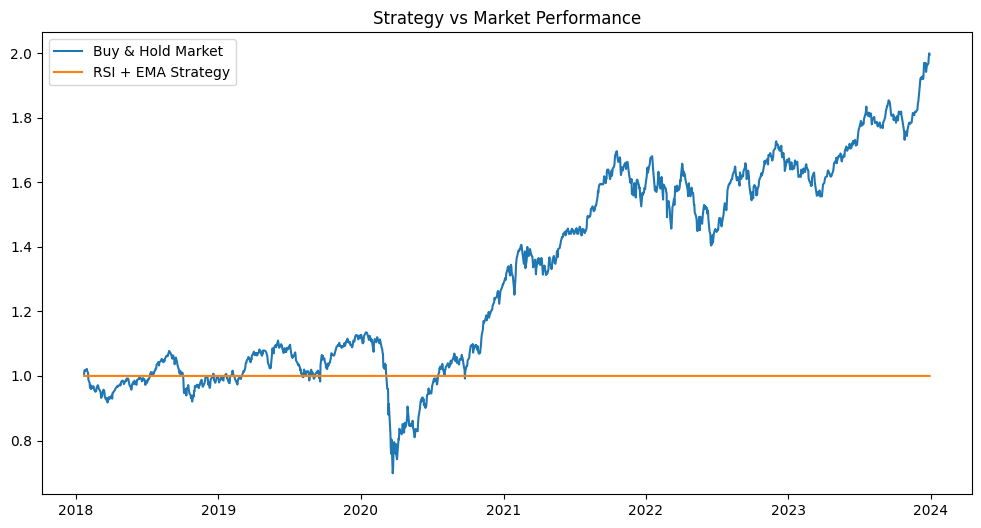

In [15]:
plt.figure(figsize=(12,6))

plt.plot(data['Market_Cumulative'], label="Buy & Hold Market")
plt.plot(data['Strategy_Cumulative'], label="RSI + EMA Strategy")

plt.title("Strategy vs Market Performance")
plt.legend()
plt.show()

In [16]:
sharpe = (data['Strategy_Returns'].mean()*252) / (data['Strategy_Returns'].std()*np.sqrt(252))

print("Sharpe Ratio:", sharpe)

Sharpe Ratio: nan


C:\Users\Tanishka Saini\AppData\Local\Temp\ipykernel_8516\2733027956.py:1: RuntimeWarning: invalid value encountered in scalar divide
  sharpe = (data['Strategy_Returns'].mean()*252) / (data['Strategy_Returns'].std()*np.sqrt(252))


In [17]:
cum_returns = data['Strategy_Cumulative']
rolling_max = cum_returns.cummax()

drawdown = (cum_returns - rolling_max) / rolling_max

print("Maximum Drawdown:", drawdown.min())

Maximum Drawdown: 0.0


In [18]:
buy_signals = data[data['Signal'] == 1]
sell_signals = data[data['Signal'] == -1]

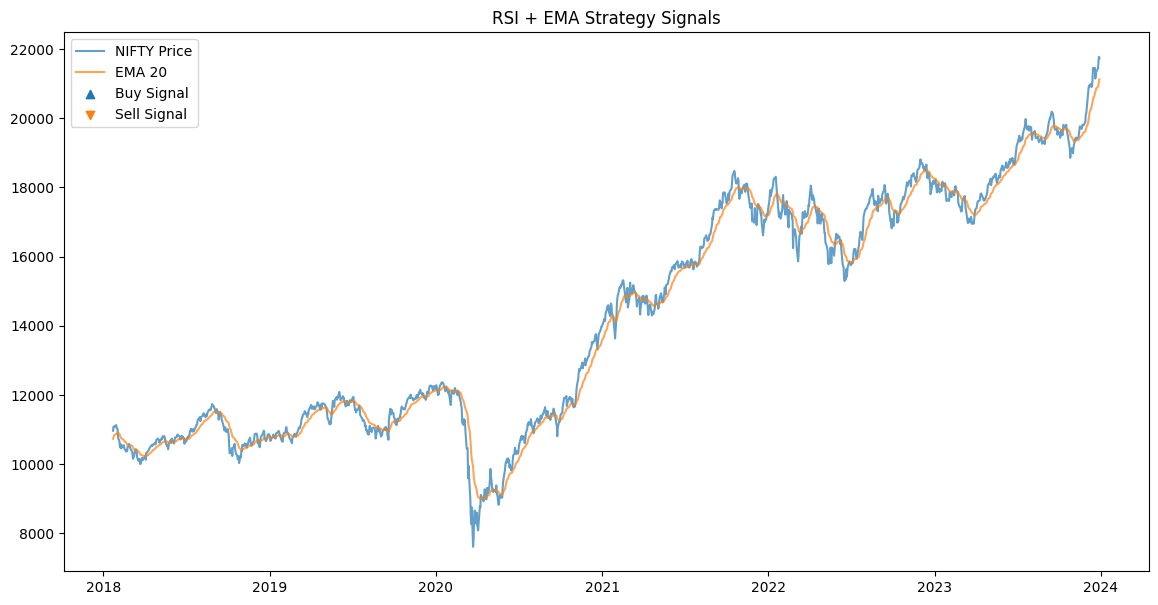

In [19]:
plt.figure(figsize=(14,7))

plt.plot(data['Close'], label="NIFTY Price", alpha=0.7)
plt.plot(data['EMA20'], label="EMA 20", alpha=0.7)

plt.scatter(buy_signals.index, buy_signals['Close'], 
            label="Buy Signal", marker="^")

plt.scatter(sell_signals.index, sell_signals['Close'], 
            label="Sell Signal", marker="v")

plt.title("RSI + EMA Strategy Signals")
plt.legend()
plt.show()

## Strategy Visualization

The chart above shows buy signals when RSI indicates oversold conditions 
while price is above the EMA trend filter.

Sell signals occur when RSI indicates overbought conditions.

This visualization helps validate whether the strategy signals align with 
meaningful market movements.

## Insights

The RSI + EMA strategy attempts to capture oversold market conditions while aligning with the trend.

The backtest shows that the strategy performs better during trending markets but suffers during sideways market regimes.

Further improvements could include stop-loss rules and parameter optimization.